# Product Features & Listing Segments

This notebook builds on the cleaned Airbnb dataset by translating raw listing data into more product-oriented signals. Instead of only modeling demand, this section explores how Airbnb could use listing attributes, amenities, pricing, host behavior, and guest-use patterns to create clearer host guidance.

The goal is to engineer practical scores such as family-friendly, work-friendly, amenity strength, host quality, pricing competitiveness, and demand tier. These features will help turn the project from a general listing analysis into a host intelligence prototype.

After creating the product scores, I will explore whether listings naturally group into meaningful segments, such as family-oriented stays, work/long-term stays, standard convenience stays, or premium/luxury-leaning listings. These segments may support better recommendations for hosts and clearer positioning for guests.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv('../data/processed/airbnb_preprocessed.csv')

## 1. Quick Data Check

Before creating product scores, I want to confirm the dataset loaded correctly and review the columns available for scoring. This step helps me see which amenity, host, pricing, location, and demand fields are already available so I can build product features from the cleanest inputs.


In [3]:
df.shape

(266350, 85)

In [4]:
df.head()

,id,host_id,room_type_hotel_room,room_type_private_room,room_type_shared_room,accommodates,bedrooms,beds,bathrooms,host_is_superhost,...,price_log,number_of_reviews_log,beds_log,accommodates_log,bedrooms_log,bathrooms_log,room_type,rating_bin,lat_bin,lon_bin
0,108061,320564,0,0,0,2,1.0,1.0,1.0,1.0,...,4.615121,4.532599,0.693147,1.098612,0.693147,0.693147,Entire home/apt,"(-0.001, 80.0]","(34.768, 36.209]","(-84.369, -79.937]"
1,155305,746673,0,0,0,2,1.0,1.0,1.0,0.0,...,4.615121,5.950643,0.693147,1.098612,0.693147,0.693147,Entire home/apt,"(-0.001, 80.0]","(34.768, 36.209]","(-84.369, -79.937]"
2,156805,746673,0,1,0,2,1.0,1.0,2.5,0.0,...,4.204693,4.219508,0.693147,1.098612,0.693147,1.252763,Private room,"(-0.001, 80.0]","(34.768, 36.209]","(-84.369, -79.937]"
3,197263,961396,0,1,0,2,1.0,1.0,1.0,1.0,...,3.828641,4.204693,0.693147,1.098612,0.693147,0.693147,Private room,"(-0.001, 80.0]","(34.768, 36.209]","(-84.369, -79.937]"
4,209068,1029919,0,0,0,4,1.0,2.0,1.0,1.0,...,4.615121,4.110874,1.098612,1.609438,0.693147,0.693147,Entire home/apt,"(-0.001, 80.0]","(34.768, 36.209]","(-84.369, -79.937]"


In [5]:
df.columns

Index(['id', 'host_id', 'room_type_hotel_room', 'room_type_private_room',
       'room_type_shared_room', 'accommodates', 'bedrooms', 'beds',
       'bathrooms', 'host_is_superhost', 'host_response_time_ord', 'price',
       'latitude', 'longitude', 'number_of_reviews', 'reviews_per_month',
       'review_scores_rating', 'instant_bookable', 'amenity_air_conditioning',
       'amenity_bathtub', 'amenity_bbq_grill', 'amenity_beach_access',
       'amenity_bed_linens', 'amenity_blender',
       'amenity_carbon_monoxide_alarm', 'amenity_cleaning_supplies',
       'amenity_coffee_maker', 'amenity_cooking_basics', 'amenity_dishwasher',
       'amenity_dryer', 'amenity_essentials', 'amenity_ev_charger',
       'amenity_fan', 'amenity_fire_extinguisher', 'amenity_fireplace',
       'amenity_first_aid_kit', 'amenity_flexible_checkin',
       'amenity_game_console', 'amenity_gym', 'amenity_hair_dryer',
       'amenity_hangers', 'amenity_heating', 'amenity_host_services',
       'amenity_hot_tub'

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 266350 entries, 0 to 266349
Data columns (total 85 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             266350 non-null  int64  
 1   host_id                        266350 non-null  int64  
 2   room_type_hotel_room           266350 non-null  int64  
 3   room_type_private_room         266350 non-null  int64  
 4   room_type_shared_room          266350 non-null  int64  
 5   accommodates                   266350 non-null  int64  
 6   bedrooms                       266350 non-null  float64
 7   beds                           266350 non-null  float64
 8   bathrooms                      266350 non-null  float64
 9   host_is_superhost              266350 non-null  float64
 10  host_response_time_ord         266350 non-null  float64
 11  price                          266350 non-null  float64
 12  latitude                       266350 non

In [7]:
# cleaning city names so grouped analysis does not split the same market into separate labels
df['city'] = df['city'].replace({
    'Dever': 'Denver',})

### Family-Friendly Score

This score gives an idea about how well a listing is suited for family travel. Features like capacity, bedrooms, kitchen/laundry, parking, bathtub, and kid-specific amenities would be most helpful. It's not a true identifier, but it could help with guest filtering and host guidance. 

If I were to take it a step further, I'd identify locations within a radius of family activities like playgrounds, amusement parks, etc. 

In [8]:
family_cols = [
    'amenity_kids_amenities',
    'amenity_kitchen',
    'amenity_washer',
    'amenity_dryer',
    'amenity_bathtub',
    'amenity_parking_free'
]

df[family_cols].sum().sort_values(ascending=False)

amenity_kitchen           238024
amenity_parking_free      199914
amenity_washer            189867
amenity_dryer             176616
amenity_bathtub           102965
amenity_kids_amenities     82916
dtype: int64

In [9]:
df['family_friendly_score'] = (
    df['amenity_kids_amenities'] * 25 +
    df['amenity_kitchen'] * 15 +
    df['amenity_washer'] * 15 +
    df['amenity_dryer'] * 15 +
    df['amenity_bathtub'] * 10 +
    df['amenity_parking_free'] * 10 +
    (df['accommodates'] >= 4).astype(int) * 10)

In [10]:
df['family_friendly_score'].describe()

count    266350.000000
mean         58.685508
std          26.241778
min           0.000000
25%          40.000000
50%          60.000000
75%          75.000000
max         100.000000
Name: family_friendly_score, dtype: float64

In [11]:
df[
    ['id', 'city', 'room_type', 'accommodates', 'bedrooms', 'bathrooms',
     'price', 'reviews_per_month', 'family_friendly_score']
].sort_values('family_friendly_score', ascending=False).head()

,id,city,room_type,accommodates,bedrooms,bathrooms,price,reviews_per_month,family_friendly_score
33,5850649,Asheville,Entire home/apt,6,1.0,1.0,68.0,3.86,100
24,5151226,Asheville,Entire home/apt,10,3.0,2.5,325.0,1.32,100
7,304379,Asheville,Entire home/apt,4,2.0,1.0,289.0,0.18,100
266328,847086881094938903,Washington Dc,Entire home/apt,8,3.0,2.5,337.0,0.00,100
83718,32912291,Hawaii,Entire home/apt,12,3.0,2.5,300.0,0.20,100


### Family-Friendly Score vs. Demand

Now that the family-friendly score is created, I want to see whether higher-scoring listings also show stronger demand. Since reviews per month is being used as a demand proxy, this comparison can help show whether family-oriented features are associated with more booking activity. This won't prove that family-friendly listings cause higher demand, but it tell me if it's worth moving forward.

In [12]:
# grouping listings by family-friendly score to compare average demand
family_score_summary = (
    df.groupby('family_friendly_score')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean')
    )
    .reset_index())

family_score_summary

,family_friendly_score,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,0,4800,0.972763,0.020,178.854375
1,10,8164,1.560087,0.580,273.408623
2,15,10164,0.536861,0.060,114.358127
3,20,2815,1.609261,0.940,235.305506
4,25,17467,1.303531,0.550,159.570161
5,30,3572,0.738052,0.070,158.283875
6,35,13286,1.559496,0.900,239.517989
7,40,9078,0.873154,0.240,166.297973
8,45,15307,0.996991,0.210,158.988829
9,50,11157,1.251816,0.470,257.715425


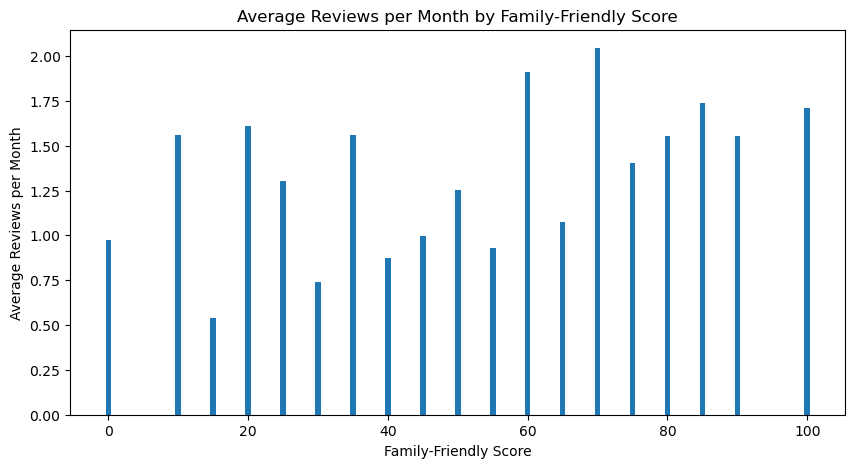

In [13]:
# plotting average demand by family-friendly score to see if there is a visible pattern
plt.figure(figsize=(10, 5))
plt.bar(family_score_summary['family_friendly_score'], family_score_summary['avg_reviews_per_month'])
plt.title('Average Reviews per Month by Family-Friendly Score')
plt.xlabel('Family-Friendly Score')
plt.ylabel('Average Reviews per Month')
plt.show()

### Family-Friendly Score Tiers

The individual score values are useful, but the pattern is a little noisy when every score is shown separately. To make this easier to interpret, I’m grouping the scores into broader tiers. This gives a clearer view of whether listings with stronger family-friendly features tend to show higher demand or pricing patterns.

In [14]:
# grouping family-friendly scores into broader tiers so the pattern is easier to read
df['family_friendly_tier'] = pd.cut(
    df['family_friendly_score'],
    bins=[-1, 25, 50, 75, 100],
    labels=['low', 'medium', 'high', 'very high']
)

# comparing demand and price across family-friendly tiers
family_tier_summary = (
    df.groupby('family_friendly_tier')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean')
    )
    .reset_index()
)

family_tier_summary

,family_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,low,43410,1.155524,0.29,177.437042
1,medium,52400,1.154766,0.36,201.646031
2,high,108454,1.183293,0.52,250.582450
3,very high,62086,1.631562,1.13,301.233982


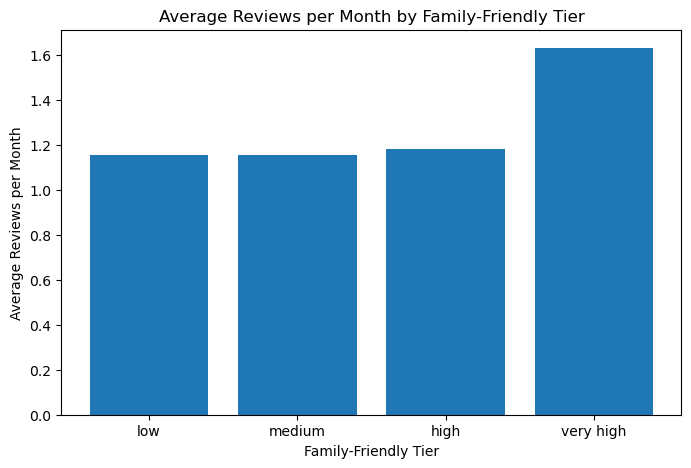

In [15]:
# plotting average demand by tier to see the broader relationship
plt.figure(figsize=(8, 5))
plt.bar(family_tier_summary['family_friendly_tier'], family_tier_summary['avg_reviews_per_month'])
plt.title('Average Reviews per Month by Family-Friendly Tier')
plt.xlabel('Family-Friendly Tier')
plt.ylabel('Average Reviews per Month')
plt.show()

The family-friendly tiers show a clearer pattern than the individual score values. Low, medium, and high scoring listings have similar avg reviews per month, but the very high tier performs better. This suggests that one or two family-friendly features may not make a big difference on their own, but listings with a more complete set of family features may be better for demand.

The very high tier also has the highest average price, so this may overlap with larger or more premium listings. This score should be useful for host guidance, but I would say it's more of a product signal.

In [16]:
# comparing family-friendly demand by city to see if the pattern holds across markets
family_city_summary = (
    df.groupby(['city', 'family_friendly_tier'])
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean')
    )
    .reset_index())

family_city_summary.head()

,city,family_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,Asheville,low,486,2.828889,2.165,137.783951
1,Asheville,medium,581,2.797367,2.280,130.039587
2,Asheville,high,1099,2.127279,1.620,171.643312
3,Asheville,very high,989,2.257543,1.850,213.856421
4,Austin,low,1270,1.301102,0.270,167.840157


### Family-Friendly Lift by City

The overall family-friendly pattern looked promising, but city-level results might tell a different story. Since each market is different, I want to compare very high family-friendly listings against the average listing in the same city. This gives a better sense of where family-friendly features may actually stand out.

In [17]:
# calculating each city's average demand so family-friendly performance is compared within the same market
city_avg_demand = (
    df.groupby('city')['reviews_per_month']
    .mean()
    .reset_index(name='city_avg_reviews_per_month'))

# pulling only very high family-friendly listings to compare against each city average
very_high_family = family_city_summary[
    family_city_summary['family_friendly_tier'] == 'very high'].copy()

# adding the city average so we can calculate lift
very_high_family = very_high_family.merge(city_avg_demand, on='city', how='left')

# calculating how much higher or lower very high family-friendly listings perform compared to the city average
very_high_family['family_demand_lift'] = (
    very_high_family['avg_reviews_per_month'] - very_high_family['city_avg_reviews_per_month'])

# sorting values to see which cities have the highest family-friendly demand lift
very_high_family.sort_values('family_demand_lift', ascending=False).head(10)

,city,family_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,family_demand_lift
30,Washington Dc,very high,1640,1.901646,1.40,231.934756,1.389933,0.511713
22,Salem,very high,91,2.056923,1.61,142.549451,1.597448,0.459476
26,Santa Clara,very high,1048,1.397548,0.90,241.681298,0.952714,0.444834
10,Fort Worth,very high,482,2.236867,2.06,169.319502,1.803926,0.432941
17,Nyc,very high,3448,1.269669,0.71,282.111949,0.889920,0.379749
6,Clark County,very high,3174,1.819401,1.47,289.349401,1.440878,0.378523
11,Hawaii,very high,6945,1.378985,1.00,447.477610,1.001028,0.377957
28,Seattle,very high,2170,2.114037,1.76,191.837788,1.771631,0.342406
7,Columbus,very high,613,2.550750,2.12,149.845024,2.214071,0.336679
1,Austin,very high,3705,1.566486,1.09,365.197841,1.234671,0.331815


In [18]:
# sorting values to see which cities have the weakest family-friendly demand lift
very_high_family.sort_values('family_demand_lift').head(10)

,city,family_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,family_demand_lift
0,Asheville,very high,989,2.257543,1.85,213.856421,2.399588,-0.142045
4,Cambridge,very high,166,1.111988,0.58,274.524096,1.091257,0.020731
21,Rhode Island,very high,1218,1.214524,0.86,395.810345,1.148819,0.065705
20,Portland,very high,1463,2.200554,1.80,146.287081,2.078765,0.121789
8,Dallas,very high,2165,1.824263,1.26,202.121940,1.697428,0.126835
27,Santa Cruz,very high,485,1.954495,1.39,378.061856,1.826006,0.128489
3,Broward,very high,6245,1.566458,1.27,350.909848,1.392596,0.173862
25,San Mateo,very high,725,1.681090,1.00,283.360000,1.503030,0.178060
24,San Francisco,very high,1240,1.261726,0.62,308.664516,1.073465,0.188260
12,Jersey City,very high,273,1.222784,0.56,261.959707,1.034387,0.188397


In [19]:
# checking the overall spread of family-friendly lift across cities
very_high_family['family_demand_lift'].describe()

count    31.000000
mean      0.255042
std       0.140516
min      -0.142045
25%       0.183160
50%       0.256068
75%       0.339543
max       0.511713
Name: family_demand_lift, dtype: float64

In [20]:
# flagging cities where very high family-friendly listings perform meaningfully above the city average
very_high_family['family_lift_group'] = pd.cut(
    very_high_family['family_demand_lift'],
    bins=[-1, 0, 0.25, 0.5, 1],
    labels=['underperforming', 'small lift', 'strong lift', 'very strong lift'])

# sorting values to see which cities respond best to family-friendly features
family_lift_summary = (
    very_high_family[
        ['city', 'listing_count', 'avg_reviews_per_month', 'city_avg_reviews_per_month',
         'family_demand_lift', 'family_lift_group']
    ]
    .sort_values('family_demand_lift', ascending=False))

family_lift_summary.head(15)

,city,listing_count,avg_reviews_per_month,city_avg_reviews_per_month,family_demand_lift,family_lift_group
30,Washington Dc,1640,1.901646,1.389933,0.511713,very strong lift
22,Salem,91,2.056923,1.597448,0.459476,strong lift
26,Santa Clara,1048,1.397548,0.952714,0.444834,strong lift
10,Fort Worth,482,2.236867,1.803926,0.432941,strong lift
17,Nyc,3448,1.269669,0.889920,0.379749,strong lift
6,Clark County,3174,1.819401,1.440878,0.378523,strong lift
11,Hawaii,6945,1.378985,1.001028,0.377957,strong lift
28,Seattle,2170,2.114037,1.771631,0.342406,strong lift
7,Columbus,613,2.550750,2.214071,0.336679,strong lift
1,Austin,3705,1.566486,1.234671,0.331815,strong lift


In [21]:
# counting cities by lift group to see how broadly the family-friendly signal applies
family_lift_summary['family_lift_group'].value_counts()

family_lift_group
strong lift         15
small lift          14
underperforming      1
very strong lift     1
Name: count, dtype: int64

### Family Friendly Lift Analysis: 

The family-friendly lift analysis shows that very high family-friendly listings perform above the city average in nearly every market, but the strength of that lift varies. A lift of 0.25 or more reviews per month was a more meaningful signal. Based on that cutoff, about half of the cities show strong or very strong lift, while the other half show only a smaller lift.

Overall, family-friendly features are useful, but they may be more valuable in certain markets like Washington DC, Salem, Santa Clara, Fort Worth, NYC, Clark County, Hawaii, Seattle, Columbus, and Austin. I would not treat this as a blanket recommendation for every host, but it could be useful for market-specific guidance.

### Work-Friendly Score

This score gives an idea about how well a listing is suited for remote work or longer stays. Features like workspace, wifi, self check-in, kitchen/laundry, private entrance, and long-term stay options would matter most for this type of guest. It's not a true identifier of work travel, but it could help identify listings that may be better positioned for remote workers, digital nomads, or guests staying longer than a quick weekend trip.

In [22]:
work_cols = [
    'amenity_workspace',
    'amenity_wifi',
    'amenity_self_checkin',
    'amenity_kitchen',
    'amenity_washer',
    'amenity_dryer',
    'amenity_private_entrance',
    'amenity_long_term_stays',
    'amenity_coffee_maker']

# checking how common each work-friendly feature is before creating the score
df[work_cols].sum().sort_values(ascending=False)

amenity_wifi                261418
amenity_kitchen             238024
amenity_coffee_maker        190329
amenity_washer              189867
amenity_dryer               176616
amenity_self_checkin        157232
amenity_workspace           137302
amenity_private_entrance    125382
amenity_long_term_stays     118463
dtype: int64

In [23]:
# creating a work-friendly score based on features that support remote work or longer stays
df['work_friendly_score'] = (
    df['amenity_workspace'] * 25 +
    df['amenity_long_term_stays'] * 20 +
    df['amenity_self_checkin'] * 15 +
    df['amenity_private_entrance'] * 10 +
    df['amenity_washer'] * 10 +
    df['amenity_dryer'] * 10 +
    df['amenity_coffee_maker'] * 5 +
    df['amenity_wifi'] * 3 +
    df['amenity_kitchen'] * 2)

In [24]:
# checking the score distribution before using it in later analysis
df['work_friendly_score'].describe()

count    266350.000000
mean         57.408999
std          27.182337
min           0.000000
25%          35.000000
50%          58.000000
75%          80.000000
max         100.000000
Name: work_friendly_score, dtype: float64

In [25]:
# sorting listings to see which ones score highest for work-friendly features
df[
    ['id', 'city', 'room_type', 'accommodates', 'bedrooms', 'bathrooms',
     'price', 'reviews_per_month', 'work_friendly_score']
].sort_values('work_friendly_score', ascending=False).head(10)

,id,city,room_type,accommodates,bedrooms,bathrooms,price,reviews_per_month,work_friendly_score
266328,847086881094938903,Washington Dc,Entire home/apt,8,3.0,2.5,337.0,0.00,100
15,4764715,Asheville,Entire home/apt,2,1.0,1.0,90.0,5.01,100
12,4448604,Asheville,Entire home/apt,4,1.0,1.0,40.0,5.51,100
233275,51820553,San Diego,Entire home/apt,6,3.0,2.0,195.0,0.35,100
233274,51818175,San Diego,Entire home/apt,14,6.0,4.5,2056.0,3.40,100
266323,846381880826071581,Washington Dc,Entire home/apt,4,2.0,2.5,134.0,0.00,100
68269,53575580,Denver,Entire home/apt,4,1.0,1.0,163.0,6.19,100
207355,610057828245818292,Oakland,Entire home/apt,4,2.0,2.0,300.0,1.00,100
70,7340132,Asheville,Entire home/apt,2,1.0,1.0,90.0,1.48,100
153540,772673885686350906,Nashville,Entire home/apt,4,1.0,1.0,83.0,4.29,100


In [26]:
# grouping work-friendly scores into broader tiers so the pattern is easier to read
df['work_friendly_tier'] = pd.cut(
    df['work_friendly_score'],
    bins=[-1, 25, 50, 75, 100],
    labels=['low', 'medium', 'high', 'very high'])

# comparing demand and price across work-friendly tiers
work_tier_summary = (
    df.groupby('work_friendly_tier')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean'))
    .reset_index())

work_tier_summary

,work_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,low,43928,0.611860,0.06,190.314310
1,medium,66880,1.069562,0.37,259.105398
2,high,85772,1.451265,0.83,242.282703
3,very high,69770,1.682858,1.14,253.371191


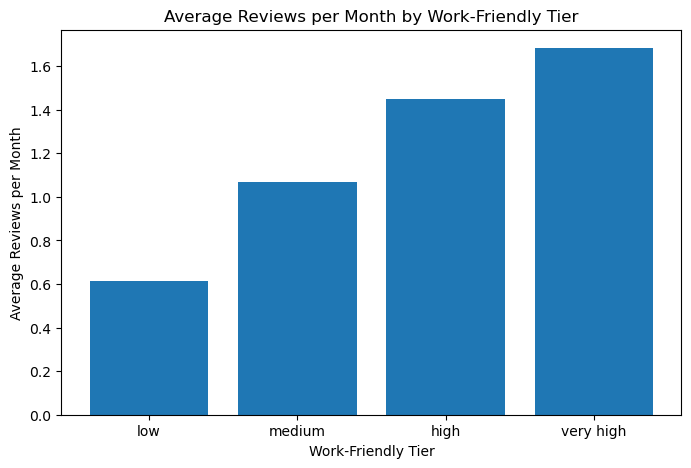

In [27]:
# plotting average demand by tier to see if work-friendly features show a broader pattern
plt.figure(figsize=(8, 5))
plt.bar(work_tier_summary['work_friendly_tier'], work_tier_summary['avg_reviews_per_month'])
plt.title('Average Reviews per Month by Work-Friendly Tier')
plt.xlabel('Work-Friendly Tier')
plt.ylabel('Average Reviews per Month')
plt.show()

The work-friendly score shows a clearer pattern than the family-friendly score. Listings with stronger work-friendly features have higher average reviews per month, with demand increasing across each tier. This suggests that remote-work and longer-stay features may be broadly useful signals for listing performance.

This still does not prove that work-friendly amenities cause higher demand, but the pattern is strong enough to keep this score as a product feature. It could help identify listings that may be better positioned for remote workers, longer stays, or guests who want convenience and flexibility.

In [28]:
# comparing work-friendly demand by city to see if the pattern holds across markets
work_city_summary = (
    df.groupby(['city', 'work_friendly_tier'])
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean'))
    .reset_index())

work_city_summary.head()

,city,work_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,Asheville,low,316,1.894019,1.00,166.411392
1,Asheville,medium,688,2.425538,1.88,154.728198
2,Asheville,high,1179,2.475360,2.03,173.745547
3,Asheville,very high,972,2.453673,2.00,183.920782
4,Austin,low,2596,0.318571,0.01,239.494992


In [29]:
# calculating each city's average demand so work-friendly performance is compared within the same market
city_avg_demand = (
    df.groupby('city')['reviews_per_month']
    .mean()
    .reset_index(name='city_avg_reviews_per_month'))

# pulling only very high work-friendly listings to compare against each city average
very_high_work = work_city_summary[
    work_city_summary['work_friendly_tier'] == 'very high'].copy()

# adding the city average so we can calculate lift
very_high_work = very_high_work.merge(city_avg_demand, on='city', how='left')

# calculating how much higher or lower very high work-friendly listings perform compared to the city average
very_high_work['work_demand_lift'] = (
    very_high_work['avg_reviews_per_month'] - very_high_work['city_avg_reviews_per_month'])

# sorting values to see which cities have the highest work-friendly demand lift
very_high_work.sort_values('work_demand_lift', ascending=False).head(10)

,city,work_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,work_demand_lift
16,Newark,very high,288,2.133924,1.640,148.958333,1.410539,0.723385
1,Austin,very high,4611,1.799063,1.350,293.127087,1.234671,0.564392
17,Nyc,very high,3808,1.451857,0.940,221.508929,0.889920,0.561937
30,Washington Dc,very high,2121,1.849986,1.340,188.603489,1.389933,0.460053
10,Fort Worth,very high,627,2.208166,1.860,153.258373,1.803926,0.404239
21,Rhode Island,very high,992,1.530423,1.070,314.501008,1.148819,0.381604
29,Twin Cities,very high,1595,1.754959,1.260,167.556740,1.387004,0.367955
5,Chicago,very high,2308,1.807422,1.515,187.228336,1.445638,0.361784
11,Hawaii,very high,5831,1.358645,0.910,358.653576,1.001028,0.357617
6,Clark County,very high,3927,1.784120,1.360,344.246499,1.440878,0.343242


In [30]:
# sorting values to see which cities have the weakest work-friendly demand lift
very_high_work.sort_values('work_demand_lift').head(10)

,city,work_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,work_demand_lift
0,Asheville,very high,972,2.453673,2.00,183.920782,2.399588,0.054085
2,Bozeman,very high,240,1.778375,1.10,246.404167,1.694899,0.083476
23,San Diego,very high,4223,1.798340,1.25,316.989818,1.649737,0.148603
14,Nashville,very high,2851,2.142999,1.73,260.798316,1.988120,0.154879
28,Seattle,very high,2545,1.934420,1.50,174.176424,1.771631,0.162790
18,Oakland,very high,727,1.384278,0.90,160.691884,1.208396,0.175882
27,Santa Cruz,very high,387,2.003798,1.47,327.596899,1.826006,0.177792
12,Jersey City,very high,329,1.238723,0.70,142.112462,1.034387,0.204337
19,Pacific Grove,very high,37,1.708108,0.64,282.081081,1.493682,0.214426
9,Denver,very high,2009,1.841722,1.19,174.430065,1.625115,0.216607


In [33]:
# grouping work-friendly lift so I can see where this signal is strongest by market
very_high_work['work_lift_group'] = pd.cut(
    very_high_work['work_demand_lift'],
    bins=[-1, 0, 0.25, 0.5, 1],
    labels=['underperforming', 'small lift', 'strong lift', 'very strong lift'])

# sorting values to see which cities respond best to work-friendly features
work_lift_summary = (
    very_high_work[
        ['city', 'listing_count', 'avg_reviews_per_month', 'city_avg_reviews_per_month',
         'work_demand_lift', 'work_lift_group']
    ]
    .sort_values('work_demand_lift', ascending=False))

work_lift_summary.head(15)

,city,listing_count,avg_reviews_per_month,city_avg_reviews_per_month,work_demand_lift,work_lift_group
16,Newark,288,2.133924,1.410539,0.723385,very strong lift
1,Austin,4611,1.799063,1.234671,0.564392,very strong lift
17,Nyc,3808,1.451857,0.889920,0.561937,very strong lift
30,Washington Dc,2121,1.849986,1.389933,0.460053,strong lift
10,Fort Worth,627,2.208166,1.803926,0.404239,strong lift
21,Rhode Island,992,1.530423,1.148819,0.381604,strong lift
29,Twin Cities,1595,1.754959,1.387004,0.367955,strong lift
5,Chicago,2308,1.807422,1.445638,0.361784,strong lift
11,Hawaii,5831,1.358645,1.001028,0.357617,strong lift
6,Clark County,3927,1.784120,1.440878,0.343242,strong lift


In [34]:
# counting cities by lift group to see how broadly the work-friendly signal applies
work_lift_summary['work_lift_group'].value_counts()

work_lift_group
small lift          15
strong lift         13
very strong lift     3
underperforming      0
Name: count, dtype: int64

The work-friendly lift analysis did better than the family-friendly analysis. Very high work friendly listings performed better than the city average in every market, with the top lift cities being Newark, Austin, and NYC. 

### Amenity Strength Score

This score gives an overall view of how well-equipped a listing is. Instead of focusing on one guest type, it looks at amenities that make a stay comfortable, easier, and convenient. Features like wifi, kitchen, self check-in, laundry, coffee maker, parking, air conditioning, heating, and basic supplies are standard expectations.

In [37]:
amenity_strength_cols = [
    'amenity_wifi',
    'amenity_kitchen',
    'amenity_self_checkin',
    'amenity_washer',
    'amenity_dryer',
    'amenity_coffee_maker',
    'amenity_parking_free',
    'amenity_air_conditioning',
    'amenity_heating',
    'amenity_cleaning_supplies',
    'amenity_essentials',
    'amenity_hot_water',
    'amenity_hangers',
    'amenity_iron']

# checking how common each practical amenity is before creating the broader amenity strength score
df[amenity_strength_cols].sum().sort_values(ascending=False)

amenity_wifi                 261418
amenity_kitchen              238024
amenity_essentials           233120
amenity_air_conditioning     223092
amenity_hangers              211262
amenity_heating              209364
amenity_hot_water            200613
amenity_iron                 200051
amenity_parking_free         199914
amenity_coffee_maker         190329
amenity_washer               189867
amenity_dryer                176616
amenity_self_checkin         157232
amenity_cleaning_supplies     92688
dtype: int64

In [38]:
# creating a broader amenity strength score based on practical features that make a stay feel complete
df['amenity_strength_score'] = (
    df['amenity_self_checkin'] * 15 +
    df['amenity_cleaning_supplies'] * 15 +
    df['amenity_parking_free'] * 10 +
    df['amenity_coffee_maker'] * 10 +
    df['amenity_washer'] * 10 +
    df['amenity_dryer'] * 10 +
    df['amenity_kitchen'] * 7 +
    df['amenity_air_conditioning'] * 7 +
    df['amenity_heating'] * 5 +
    df['amenity_hot_water'] * 4 +
    df['amenity_essentials'] * 3 +
    df['amenity_wifi'] * 2 +
    df['amenity_hangers'] * 1 +
    df['amenity_iron'] * 1)

In [39]:
# checking the score distribution before using it in later analysis
df['amenity_strength_score'].describe()

count    266350.000000
mean         67.680319
std          23.302952
min           0.000000
25%          52.000000
50%          70.000000
75%          85.000000
max         100.000000
Name: amenity_strength_score, dtype: float64

In [41]:
# grouping amenity strength scores into broader tiers so the pattern is easier to read
df['amenity_strength_tier'] = pd.cut(
    df['amenity_strength_score'],
    bins=[-1, 25, 50, 75, 100],
    labels=['low', 'medium', 'high', 'very high'])

In [43]:
# comparing demand and price across amenity strength tiers
amenity_tier_summary = (
    df.groupby('amenity_strength_tier')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean'))
    .reset_index())

amenity_tier_summary

,amenity_strength_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,low,14322,0.399700,0.01,167.455872
1,medium,48814,0.755330,0.13,234.471770
2,high,92828,1.184798,0.46,243.584005
3,very high,110386,1.700609,1.19,250.871052


In [44]:
# comparing amenity strength by city to see if the pattern holds across markets
amenity_city_summary = (
    df.groupby(['city', 'amenity_strength_tier'])
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean'))
    .reset_index())

amenity_city_summary.head()

,city,amenity_strength_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,Asheville,low,44,0.989091,0.525,138.386364
1,Asheville,medium,298,1.866611,1.000,177.151007
2,Asheville,high,1076,2.642500,2.070,149.845725
3,Asheville,very high,1737,2.376281,1.950,185.689119
4,Austin,low,328,0.230061,0.000,195.164634


In [45]:
# calculating each city's average demand so amenity strength is compared within the same market
city_avg_demand = (
    df.groupby('city')['reviews_per_month']
    .mean()
    .reset_index(name='city_avg_reviews_per_month'))

# pulling very high amenity strength listings to compare against each city average
very_high_amenity = amenity_city_summary[
    amenity_city_summary['amenity_strength_tier'] == 'very high'].copy()

# adding the city average so we can calculate lift
very_high_amenity = very_high_amenity.merge(city_avg_demand, on='city', how='left')

# calculating how much higher or lower very high amenity listings perform compared to the city average
very_high_amenity['amenity_demand_lift'] = (
    very_high_amenity['avg_reviews_per_month'] - very_high_amenity['city_avg_reviews_per_month'])

# sorting values to see which cities have the highest amenity strength lift
very_high_amenity.sort_values('amenity_demand_lift', ascending=False).head(10)

,city,amenity_strength_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,amenity_demand_lift
17,Nyc,very high,7436,1.617505,1.10,202.685046,0.889920,0.727585
16,Newark,very high,451,1.999246,1.38,146.771619,1.410539,0.588707
30,Washington Dc,very high,2667,1.912456,1.41,196.037870,1.389933,0.522523
1,Austin,very high,7039,1.673472,1.18,299.792016,1.234671,0.438801
5,Chicago,very high,3584,1.811747,1.56,178.611328,1.445638,0.366109
11,Hawaii,very high,10251,1.359158,0.96,388.931031,1.001028,0.358130
2,Bozeman,very high,359,2.036490,1.51,231.662953,1.694899,0.341591
28,Seattle,very high,3464,2.107719,1.69,171.674654,1.771631,0.336089
3,Broward,very high,7632,1.719569,1.41,301.022275,1.392596,0.326973
29,Twin Cities,very high,2611,1.712895,1.22,173.510532,1.387004,0.325892


In [46]:
# sorting values to see which cities have the weakest amenity strength lift
very_high_amenity.sort_values('amenity_demand_lift').head(10)

,city,amenity_strength_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,amenity_demand_lift
0,Asheville,very high,1737,2.376281,1.950,185.689119,2.399588,-0.023307
27,Santa Cruz,very high,757,1.836301,1.220,365.873184,1.826006,0.010295
19,Pacific Grove,very high,60,1.582333,0.850,321.766667,1.493682,0.088652
12,Jersey City,very high,546,1.206117,0.660,198.813187,1.034387,0.171730
18,Oakland,very high,1023,1.391144,0.910,164.780059,1.208396,0.182748
4,Cambridge,very high,251,1.278367,0.640,247.673307,1.091257,0.187109
21,Rhode Island,very high,2208,1.346277,0.945,314.817935,1.148819,0.197458
8,Dallas,very high,3909,1.896897,1.390,177.014070,1.697428,0.199468
22,Salem,very high,174,1.800862,1.275,123.356322,1.597448,0.203415
25,San Mateo,very high,1423,1.717822,1.160,236.827829,1.503030,0.214791


# grouping amenity strength lift so I can see where this signal is strongest by market
very_high_amenity['amenity_lift_group'] = pd.cut(
    very_high_amenity['amenity_demand_lift'],
    bins=[-1, 0, 0.25, 0.5, 1],
    labels=['underperforming', 'small lift', 'strong lift', 'very strong lift'])

# sorting values to see which cities respond best to very high amenity strength
amenity_lift_summary = (
    very_high_amenity[
        ['city', 'listing_count', 'avg_reviews_per_month', 'city_avg_reviews_per_month',
         'amenity_demand_lift', 'amenity_lift_group']]
    .sort_values('amenity_demand_lift', ascending=False))

amenity_lift_summary.head(15)

In [50]:
# counting cities by lift group to see how broadly amenity strength applies
amenity_lift_summary['amenity_lift_group'].value_counts()

amenity_lift_group
small lift          14
strong lift         13
very strong lift     3
underperforming      1
Name: count, dtype: int64

The amenity strength score did OK, but didn't perform as well as the work amenity score. Listings with very high strenth did perform above the city average. 

### Host Quality Score

This score gives an idea about how strong a listing’s host and trust signals are. Features like Superhost status, response time, instant booking, and review score signal trust for renters. This is not a perfect measure of host quality, but it gives an idea of how reliable the host is. 

In [53]:
host_cols = [
    'host_is_superhost',
    'host_response_time_ord',
    'instant_bookable',
    'review_scores_rating']

# checking the host-related fields before creating the host quality score
df[host_cols].describe()

,host_is_superhost,host_response_time_ord,instant_bookable,review_scores_rating
count,266350.000000,266350.000000,266350.000000,266350.000000
mean,0.365099,2.082110,0.328252,3.748910
std,0.481459,1.513422,0.469578,1.975605
min,0.000000,-1.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,4.000000
50%,0.000000,3.000000,0.000000,4.800000
75%,1.000000,3.000000,1.000000,4.970000
max,1.000000,3.000000,1.000000,5.000000


In [54]:
# creating a cleaner response time field so missing values do not lower the host quality score unfairly
df['host_response_score'] = df['host_response_time_ord'].replace(-1, 0)

In [56]:
# creating a host quality score based on trust signals guests may use before booking
df['host_quality_score'] = (
    df['host_is_superhost'] * 25 +
    df['instant_bookable'] * 15 +
    df['host_response_score'] / 3 * 25 +
    df['review_scores_rating'] / 5 * 35)

In [57]:
# checking the score distribution before using it in later analysis
df['host_quality_score'].describe()

count    266350.000000
mean         59.065130
std          26.547044
min           0.000000
25%          40.000000
50%          60.000000
75%          83.600000
max         100.000000
Name: host_quality_score, dtype: float64

In [59]:
# grouping host quality scores into broader tiers so the pattern is easier to read
df['host_quality_tier'] = pd.cut(
    df['host_quality_score'],
    bins=[-1, 25, 50, 75, 100],
    labels=['low', 'medium', 'high', 'very high'])

# comparing demand and price across host quality tiers
host_tier_summary = (
    df.groupby('host_quality_tier')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean'))
    .reset_index())

host_tier_summary

,host_quality_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,low,35044,0.004154,0.00,267.113400
1,medium,59328,0.444454,0.10,259.124174
2,high,90067,1.462765,0.96,223.959075
3,very high,81911,2.222412,1.82,234.919767


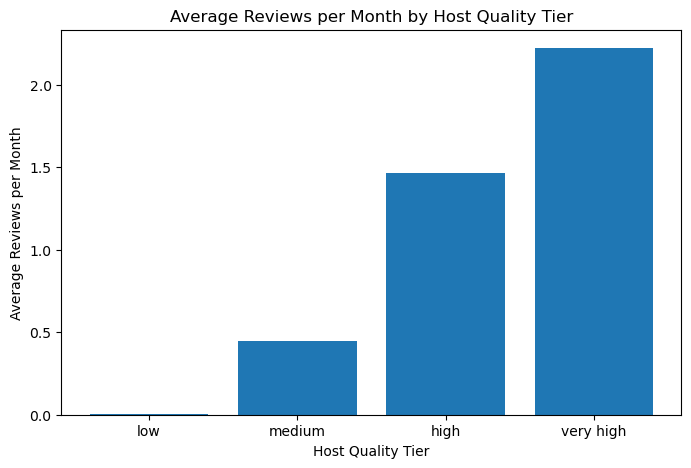

In [60]:
# plotting average demand by tier to see if stronger host signals are tied to demand
plt.figure(figsize=(8, 5))
plt.bar(host_tier_summary['host_quality_tier'], host_tier_summary['avg_reviews_per_month'])
plt.title('Average Reviews per Month by Host Quality Tier')
plt.xlabel('Host Quality Tier')
plt.ylabel('Average Reviews per Month')
plt.show()

The host quality score shows the strongest demand pattern so far. Listings in the very high host quality tier have much higher average and median reviews per month than the lower tiers. What I think is really interesting is that they're not the most expensive, meaning they're more seasoned and don't need to rely on high prices since they get more consistent demand OR they have smaller/more rentable listings that are more consistently booked out.

This score should be interpreted carefully because review score is part of the host quality score, and listings with few or no reviews may naturally fall into lower tiers. Either way, the pattern supports the idea that Superhost status, response behavior, instant booking, and strong ratings can help listings feel more reliable to renters.

In [62]:
# comparing host quality by city to see if the pattern holds across markets
host_city_summary = (
    df.groupby(['city', 'host_quality_tier'])
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean'))
    .reset_index())

host_city_summary.head()

,city,host_quality_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,Asheville,low,134,0.004030,0.00,238.776119
1,Asheville,medium,417,0.919880,0.41,183.707434
2,Asheville,high,701,1.923167,1.42,165.158345
3,Asheville,very high,1903,3.068014,2.59,167.250657
4,Austin,low,2252,0.003588,0.00,329.924067


In [64]:
# calculating each city's average demand so host quality is compared within the same market
city_avg_demand = (
    df.groupby('city')['reviews_per_month']
    .mean()
    .reset_index(name='city_avg_reviews_per_month'))

# pulling very high host quality listings to compare against each city average
very_high_host = host_city_summary[
    host_city_summary['host_quality_tier'] == 'very high'
].copy()

# adding the city average so we can calculate lift
very_high_host = very_high_host.merge(city_avg_demand, on='city', how='left')

# calculating how much higher or lower very high host quality listings perform compared to the city average
very_high_host['host_demand_lift'] = (
    very_high_host['avg_reviews_per_month'] - very_high_host['city_avg_reviews_per_month'])

# sorting values to see which cities have the highest host quality lift
very_high_host.sort_values('host_demand_lift', ascending=False).head(10)

,city,host_quality_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,host_demand_lift
30,Washington Dc,very high,1736,2.665743,2.300,194.462558,1.389933,1.275810
16,Newark,very high,233,2.645279,2.370,123.115880,1.410539,1.234740
12,Jersey City,very high,278,2.168813,1.895,134.550360,1.034387,1.134426
27,Santa Cruz,very high,675,2.953778,2.470,277.622222,1.826006,1.127772
17,Nyc,very high,7461,2.011045,1.610,177.220212,0.889920,1.121126
1,Austin,very high,4269,2.316414,1.880,272.711876,1.234671,1.081742
8,Dallas,very high,1623,2.757160,2.300,189.207640,1.697428,1.059731
13,Los Angeles,very high,10879,2.100311,1.600,226.734626,1.054250,1.046061
4,Cambridge,very high,272,2.039191,1.390,181.827206,1.091257,0.947934
25,San Mateo,very high,1116,2.424812,2.000,218.557348,1.503030,0.921782


In [66]:
# sorting values to see which cities have the weakest lift
very_high_host.sort_values('host_demand_lift').head(10)

,city,host_quality_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,host_demand_lift
7,Columbus,very high,1042,2.769578,2.405,135.611324,2.214071,0.555507
2,Bozeman,very high,289,2.286644,1.900,227.235294,1.694899,0.591745
15,New Orleans,very high,2692,2.274257,2.010,233.174220,1.645294,0.628963
0,Asheville,very high,1903,3.068014,2.590,167.250657,2.399588,0.668426
11,Hawaii,very high,10517,1.677088,1.230,383.600742,1.001028,0.676060
29,Twin Cities,very high,1913,2.064009,1.670,159.810768,1.387004,0.677006
3,Broward,very high,4995,2.078629,1.790,291.891692,1.392596,0.686033
14,Nashville,very high,3899,2.684014,2.310,258.265709,1.988120,0.695893
24,San Francisco,very high,2370,1.785730,1.075,216.049789,1.073465,0.712264
22,Salem,very high,148,2.330676,1.660,112.229730,1.597448,0.733228


In [67]:
# grouping host quality lift so I can see where this signal is strongest by market
very_high_host['host_lift_group'] = pd.cut(
    very_high_host['host_demand_lift'],
    bins=[-1, 0, 0.25, 0.5, 1.5],
    labels=['underperforming', 'small lift', 'strong lift', 'very strong lift']
)

# sorting values to see which cities respond best to very high host quality
host_lift_summary = (
    very_high_host[
        ['city', 'listing_count', 'avg_reviews_per_month', 'city_avg_reviews_per_month',
         'host_demand_lift', 'host_lift_group']
    ]
    .sort_values('host_demand_lift', ascending=False)
)

host_lift_summary.head(15)

,city,listing_count,avg_reviews_per_month,city_avg_reviews_per_month,host_demand_lift,host_lift_group
30,Washington Dc,1736,2.665743,1.389933,1.275810,very strong lift
16,Newark,233,2.645279,1.410539,1.234740,very strong lift
12,Jersey City,278,2.168813,1.034387,1.134426,very strong lift
27,Santa Cruz,675,2.953778,1.826006,1.127772,very strong lift
17,Nyc,7461,2.011045,0.889920,1.121126,very strong lift
1,Austin,4269,2.316414,1.234671,1.081742,very strong lift
8,Dallas,1623,2.757160,1.697428,1.059731,very strong lift
13,Los Angeles,10879,2.100311,1.054250,1.046061,very strong lift
4,Cambridge,272,2.039191,1.091257,0.947934,very strong lift
25,San Mateo,1116,2.424812,1.503030,0.921782,very strong lift


In [68]:
# counting cities by lift group to see how broadly host quality applies
host_lift_summary['host_lift_group'].value_counts()

host_lift_group
very strong lift    31
underperforming      0
small lift           0
strong lift          0
Name: count, dtype: int64

In [69]:
# checking the spread of host quality lift before setting better lift groups
very_high_host['host_demand_lift'].describe()

count    31.000000
mean      0.867127
std       0.192868
min       0.555507
25%       0.704079
50%       0.843082
75%       0.996997
max       1.275810
Name: host_demand_lift, dtype: float64

# grouping host quality lift with wider bins because this signal is much stronger than the other scores
very_high_host['host_lift_group'] = pd.cut(
    very_high_host['host_demand_lift'],
    bins=[-1, 0.25, 0.75, 1.25, 2],
    labels=['small lift', 'strong lift', 'very strong lift', 'exceptional lift']
)

# rebuilding the host lift summary with the updated groups
host_lift_summary = (
    very_high_host[
        ['city', 'listing_count', 'avg_reviews_per_month', 'city_avg_reviews_per_month',
         'host_demand_lift', 'host_lift_group']
    ]
    .sort_values('host_demand_lift', ascending=False)
)

host_lift_summary.head(15)

In [71]:
# counting cities by updated host lift group
host_lift_summary['host_lift_group'].value_counts()

host_lift_group
very strong lift    20
strong lift         10
exceptional lift     1
small lift           0
Name: count, dtype: int64

Host quality shows the most consistent lift across the board. Every city shows at least strong lift for very high host quality listings, and most cities fall into the very strong lift group. It shows that host trust signals matter across markets more consistently than guest-type scores like family-friendly or work-friendly.

### Pricing Competitiveness Score

This score gives an idea about whether a listing is priced competitively compared to similar listings in the same market. Instead of comparing every listing against the full dataset, I’m comparing listings by city, room type, and capacity. This gives a more realistic peer group because price expectations are different across markets and listing types (ie: A Denver condo can't be compared to a full house in Hawaii).

In [72]:
# creating capacity groups so listings are compared against similar-sized listings
df['capacity_group'] = pd.cut(
    df['accommodates'],
    bins=[0, 2, 4, 6, 20],
    labels=['1-2 guests', '3-4 guests', '5-6 guests', '7+ guests'])

# calculating the median peer price by city, room type, and capacity group
peer_price = (
    df.groupby(['city', 'room_type', 'capacity_group'])['price']
    .median()
    .reset_index(name='peer_median_price'))

# adding the peer median price back to the main dataframe
df = df.merge(
    peer_price,
    on=['city', 'room_type', 'capacity_group'],
    how='left')

# calculating how far each listing's price is from its peer median
df['price_vs_peer'] = (
    (df['price'] - df['peer_median_price']) / df['peer_median_price'])

In [73]:
# checking the pricing comparison fields before creating the score
df[['price', 'peer_median_price', 'price_vs_peer']].describe()

C:\Users\cococ\miniconda3\envs\ds\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,price,peer_median_price,price_vs_peer
count,266350.000000,266295.000000,2.662890e+05
mean,240.840533,190.229276,inf
std,287.509424,138.317648,NaN
min,0.000000,0.000000,-1.000000e+00
25%,95.000000,110.000000,-2.677165e-01
50%,154.000000,161.000000,0.000000e+00
75%,271.000000,255.000000,4.137931e-01
max,3150.000000,2100.000000,inf


In [74]:
# replacing zero prices with missing values so they do not distort peer pricing comparisons
df['price_clean'] = df['price'].replace(0, np.nan)

In [76]:
# recalculating peer median price using the cleaned price field
peer_price = (
    df.groupby(['city', 'room_type', 'capacity_group'])['price_clean']
    .median()
    .reset_index(name='peer_median_price'))

# dropping the earlier peer price columns before merging the corrected version
df = df.drop(columns=['peer_median_price', 'price_vs_peer'], errors='ignore')

# adding the corrected peer median price back to the main dataframe
df = df.merge(
    peer_price,
    on=['city', 'room_type', 'capacity_group'],
    how='left')

# calculating how far each listing's price is from its peer median
df['price_vs_peer'] = (
    (df['price_clean'] - df['peer_median_price']) / df['peer_median_price'])

In [77]:
# checking the pricing comparison fields after removing zero-price distortion
df[['price_clean', 'peer_median_price', 'price_vs_peer']].describe()

,price_clean,peer_median_price,price_vs_peer
count,266271.000000,266293.000000,266271.000000
mean,240.911988,190.249778,0.270539
std,287.522137,138.323427,1.205064
min,1.000000,22.500000,-0.995763
25%,95.000000,110.000000,-0.267500
50%,155.000000,161.000000,0.000000
75%,271.000000,255.000000,0.413793
max,3150.000000,2100.000000,52.152542


In [79]:
# capping extreme price differences so one outlier does not distort the pricing score
df['price_vs_peer_capped'] = df['price_vs_peer'].clip(lower=-1, upper=2)

In [80]:
# creating a pricing competitiveness score where listings closer to or below peer median score higher
df['pricing_competitiveness_score'] = (
    100 - (df['price_vs_peer_capped'].abs() * 100)).clip(lower=0, upper=100)

In [81]:
# checking the score distribution before using it in later analysis
df['pricing_competitiveness_score'].describe()

count    266271.000000
mean         61.077050
std          30.321949
min           0.000000
25%          45.731707
50%          68.623853
75%          85.000000
max         100.000000
Name: pricing_competitiveness_score, dtype: float64

In [83]:
# grouping pricing competitiveness scores into broader tiers so the pattern is easier to read
df['pricing_competitiveness_tier'] = pd.cut(
    df['pricing_competitiveness_score'],
    bins=[-1, 25, 50, 75, 100],
    labels=['low', 'medium', 'high', 'very high'])

# comparing demand and price across pricing competitiveness tiers
pricing_tier_summary = (
    df.groupby('pricing_competitiveness_tier')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price_clean', 'mean'),
        avg_peer_price=('peer_median_price', 'mean'))
    .reset_index())

pricing_tier_summary

,pricing_competitiveness_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_peer_price
0,low,42351,0.773825,0.20,585.347194,208.950485
1,medium,33921,1.220252,0.55,202.258041,210.180906
2,high,82177,1.366055,0.69,163.937075,185.484241
3,very high,107822,1.425718,0.77,176.449936,180.250515


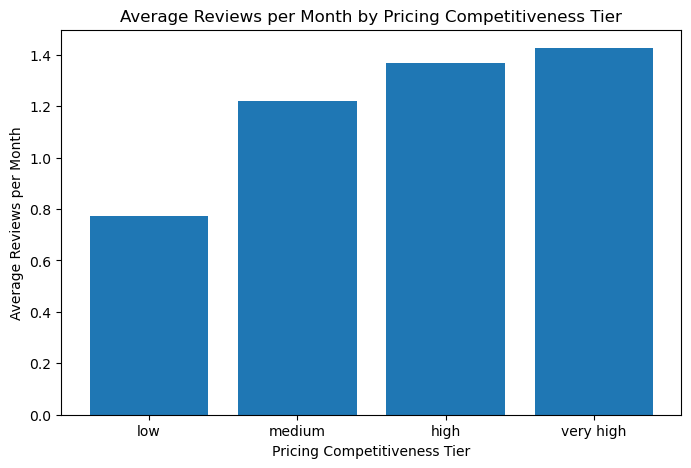

In [84]:
# plotting average demand by pricing tier to see if competitive pricing is tied to higher demand
plt.figure(figsize=(8, 5))
plt.bar(pricing_tier_summary['pricing_competitiveness_tier'], pricing_tier_summary['avg_reviews_per_month'])
plt.title('Average Reviews per Month by Pricing Competitiveness Tier')
plt.xlabel('Pricing Competitiveness Tier')
plt.ylabel('Average Reviews per Month')
plt.show()

This shows that over pricing might hurt bookings. 

Listings that are priced closer to similar listings in the same city, room type, and capacity group have higher average reviews per month. 

This does not mean the cheapest listings always perform best. The score is based on closeness to the peer median, not low price alone. This makes it more useful for host guidance because it compares each listing to a realistic local benchmark.

In [86]:
# summarizing all product scores to compare how each one relates to demand and price
score_summary = pd.DataFrame({
    'score': [
        'family_friendly_score',
        'work_friendly_score',
        'amenity_strength_score',
        'host_quality_score',
        'pricing_competitiveness_score'
    ],
    'avg_score': [
        df['family_friendly_score'].mean(),
        df['work_friendly_score'].mean(),
        df['amenity_strength_score'].mean(),
        df['host_quality_score'].mean(),
        df['pricing_competitiveness_score'].mean()
    ],
    'median_score': [
        df['family_friendly_score'].median(),
        df['work_friendly_score'].median(),
        df['amenity_strength_score'].median(),
        df['host_quality_score'].median(),
        df['pricing_competitiveness_score'].median()
    ],
    'correlation_with_reviews_per_month': [
        df['family_friendly_score'].corr(df['reviews_per_month']),
        df['work_friendly_score'].corr(df['reviews_per_month']),
        df['amenity_strength_score'].corr(df['reviews_per_month']),
        df['host_quality_score'].corr(df['reviews_per_month']),
        df['pricing_competitiveness_score'].corr(df['reviews_per_month'])
    ],
    'correlation_with_price': [
        df['family_friendly_score'].corr(df['price_clean']),
        df['work_friendly_score'].corr(df['price_clean']),
        df['amenity_strength_score'].corr(df['price_clean']),
        df['host_quality_score'].corr(df['price_clean']),
        df['pricing_competitiveness_score'].corr(df['price_clean'])
    ]
})

score_summary.sort_values('correlation_with_reviews_per_month', ascending=False)

,score,avg_score,median_score,correlation_with_reviews_per_month,correlation_with_price
3,host_quality_score,59.065130,60.000000,0.443214,-0.023783
2,amenity_strength_score,67.680319,70.000000,0.238057,0.047128
1,work_friendly_score,57.408999,58.000000,0.189118,0.054360
4,pricing_competitiveness_score,61.077050,68.623853,0.123077,-0.454860
0,family_friendly_score,58.685508,60.000000,0.097787,0.170439


### Product Score Summary

The score summary helps compare which product signals are most closely associated with demand. Host quality has the strongest relationship with reviews per month, followed by amenity strength, work-friendly features, pricing competitiveness, and family-friendly features.

It shows trust and reliability might matter more consistently than guest-type positioning alone. Practical amenities and work-friendly features impact demand, while family-friendly features seem more market-specific. The pricing competitiveness score shows that listings perform better when their price is close to similar listings in the same market; they'll perform better and make more sense for guests.

In [87]:
# creating one combined product score from the main host, amenity, pricing, and guest-fit signals
df['listing_product_score'] = (
    df['host_quality_score'] * 0.35 +
    df['amenity_strength_score'] * 0.25 +
    df['pricing_competitiveness_score'] * 0.20 +
    df['work_friendly_score'] * 0.10 +
    df['family_friendly_score'] * 0.10
)

In [88]:
# checking the combined product score before using it for segments or final recommendations
df['listing_product_score'].describe()

count    266271.000000
mean         61.426009
std          17.964622
min           0.000000
25%          49.400000
50%          63.554500
75%          75.066551
max         100.000000
Name: listing_product_score, dtype: float64

In [90]:
# grouping the combined product score into tiers so it can be used for recommendations
df['listing_product_tier'] = pd.cut(
    df['listing_product_score'],
    bins=[-1, 25, 50, 75, 100],
    labels=['low', 'medium', 'high', 'very high'])

# comparing demand and price across the combined product score tiers
product_tier_summary = (
    df.groupby('listing_product_tier')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price_clean', 'mean'))
    .reset_index())

product_tier_summary

,listing_product_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,low,8809,0.023078,0.00,368.075832
1,medium,60196,0.375953,0.02,278.600787
2,high,130317,1.333500,0.72,233.292118
3,very high,66949,2.143942,1.78,205.125006


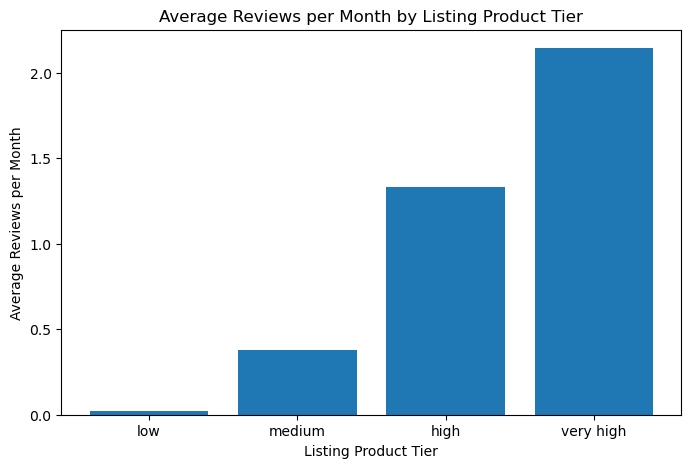

In [91]:
# plotting average demand by product tier to see if the combined score gives a useful ranking
plt.figure(figsize=(8, 5))
plt.bar(product_tier_summary['listing_product_tier'], product_tier_summary['avg_reviews_per_month'])
plt.title('Average Reviews per Month by Listing Product Tier')
plt.xlabel('Listing Product Tier')
plt.ylabel('Average Reviews per Month')
plt.show()

The combined product score has a pretty clear pattern. Listings with higher scores also tend to have more reviews per month. The very high tier performs the best, which tells me this score is probably capturing some useful demand.

The score combines host quality, amenities, pricing, work-friendly features, and family-friendly features, so I would use it more as a guide. It helps compare listings and gives a starting point for where hosts might improve.

### Listing Segments

After creating the product scores, I want to see whether listings naturally group into different types. This is different from predicting demand. The goal is to explore whether listings cluster around certain patterns, like strong host quality, work-friendly setup, family-friendly setup, or weaker overall product signals.

I am only using the product scores for clustering, not reviews per month. This keeps demand separate so I can compare performance after the segments are created.

In [96]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

segment_cols = [
    'family_friendly_score',
    'work_friendly_score',
    'amenity_strength_score',
    'host_quality_score',
    'pricing_competitiveness_score',
    'listing_product_score']

# dropping rows with missing score values before clustering
segment_df = df[segment_cols].dropna()

# scaling scores so each one contributes more evenly to the clustering
scaler = StandardScaler()
segment_scaled = scaler.fit_transform(segment_df)

In [98]:
# testing a few cluster counts to see where the improvement starts to slow down
inertia = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(segment_scaled)
    inertia.append(kmeans.inertia_)

# saving the elbow results in a dataframe so they are easier to read
elbow_df = pd.DataFrame({
    'k': range(2, 7),
    'inertia': inertia
})

elbow_df

,k,inertia
0,2,949126.175370
1,3,794566.357557
2,4,672161.801923
3,5,602815.894489
4,6,540775.340746


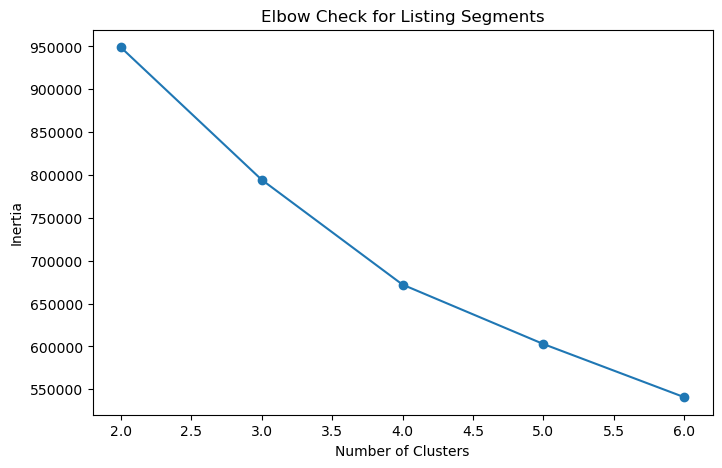

In [99]:
# plotting the elbow curve to help choose a reasonable number of listing segments
plt.figure(figsize=(8, 5))
plt.plot(elbow_df['k'], elbow_df['inertia'], marker='o')
plt.title('Elbow Check for Listing Segments')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

There isn't an obvious elbow, so this is just exploratory. I chose 4 clusters because it gives enough separation to compare different listing types without creating too many groups to explain clearly.

In [101]:
# creating 4 listing segments based on the product scores
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
segment_labels = kmeans.fit_predict(segment_scaled)

# adding the cluster labels back to the rows used for clustering
segment_df = segment_df.copy()
segment_df['listing_segment'] = segment_labels

# adding the segment labels back to the main dataframe
df.loc[segment_df.index, 'listing_segment'] = segment_df['listing_segment']

In [102]:
# comparing average score patterns across each listing segment
segment_summary = (
    df.groupby('listing_segment')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price_clean', 'mean'),
        avg_family_score=('family_friendly_score', 'mean'),
        avg_work_score=('work_friendly_score', 'mean'),
        avg_amenity_score=('amenity_strength_score', 'mean'),
        avg_host_score=('host_quality_score', 'mean'),
        avg_pricing_score=('pricing_competitiveness_score', 'mean'),
        avg_product_score=('listing_product_score', 'mean')
    )
    .reset_index()
)

segment_summary

,listing_segment,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_family_score,avg_work_score,avg_amenity_score,avg_host_score,avg_pricing_score,avg_product_score
0,0.0,80897,1.430788,0.75,159.903865,48.702980,50.113317,62.732858,61.939904,75.729417,62.389694
1,1.0,86703,1.872132,1.44,203.376573,80.280671,81.186995,88.508437,74.769566,75.346506,79.512525
2,2.0,41712,0.952330,0.40,482.918968,71.660074,67.585491,77.425537,57.770870,16.735566,56.847858
3,3.0,56959,0.392511,0.01,235.875946,30.539335,24.178743,35.921768,32.065330,51.017792,35.878674


The clustering step created 4 listing segments based on the product scores. Segment 1 looks like the strongest all around, with high scores for family-friendly, work-friendly, amenity strength, host quality, pricing competitiveness, and overall product score. It also has the highest average and median reviews per month.

Segment 2 is interesting because it has the highest average price, but a much lower pricing competitiveness score and lower demand. This could mean listings with decent features might still underperform if they are priced too far above similar listings.

These are exploratory segments - they show different listing patterns and could be used as a starting point for host guidance.

In [104]:
# naming the clusters based on the average score patterns in each segment
segment_names = {
    0: 'standard_price_aligned',
    1: 'strong_all_around',
    2: 'premium_overpriced',
    3: 'weak_product_signal'}

df['listing_segment_name'] = df['listing_segment'].map(segment_names)

In [105]:
# checking how many listings fall into each named segment
df['listing_segment_name'].value_counts()

listing_segment_name
strong_all_around         86703
standard_price_aligned    80897
weak_product_signal       56959
premium_overpriced        41712
Name: count, dtype: int64

In [106]:
# saving the final dataset with product scores so it can be used for modeling and recommendations
df.to_csv('../data/processed/airbnb_product_features.csv', index=False)

In [107]:
# checking that the final product feature dataset saved correctly
product_check = pd.read_csv('../data/processed/airbnb_product_features.csv')
product_check.shape

(266350, 105)

In [108]:
# checking that the final product scores and segments were saved
product_cols = [
    'family_friendly_score',
    'work_friendly_score',
    'amenity_strength_score',
    'host_quality_score',
    'pricing_competitiveness_score',
    'listing_product_score',
    'listing_product_tier',
    'listing_segment',
    'listing_segment_name'
]

product_check[product_cols].head()

,family_friendly_score,work_friendly_score,amenity_strength_score,host_quality_score,pricing_competitiveness_score,listing_product_score,listing_product_tier,listing_segment,listing_segment_name
0,80,60,85,81.570000,98.477157,83.494931,very high,1.0,strong_all_around
1,25,35,65,57.130000,98.477157,61.940931,high,0.0,standard_price_aligned
2,25,25,56,71.640000,86.842105,61.442421,high,0.0,standard_price_aligned
3,90,50,74,76.316667,59.210526,71.052939,high,1.0,strong_all_around
4,90,85,85,75.756667,81.300813,81.524996,very high,1.0,strong_all_around


### Final Summary

In this notebook, I created product-focused scores to better understand how listings compare across family-friendly features, work-friendly features, amenity strength, host quality, pricing competitiveness, and overall product strength.

The strongest signal was host quality, which had the highest relationship with reviews per month. Amenity strength and work-friendly features also looked useful, while family-friendly features seemed more market-specific. Pricing competitiveness showed that listings closer to similar listings in their market tended to perform better than listings priced too far outside their peer group.

I also created a combined product score and used clustering to group listings into 4 segments to explore.